# Detecting Topic Merges and Splits in Dynamic Political Conversations

Cláudia Oliveira

Supervisor - Prof. Dr. Álvaro Figueira

Faculty of Science, University of Porto

In [1]:
%%capture
!pip install  sentence-transformers  gensim scikit-learn pandas  tqdm emoji rapidfuzz nltk
import nltk
nltk.download('stopwords')
!pip install -U numpy==1.26.4
!pip install -U scipy==1.11.4
!pip install -U hdbscan==0.8.33
!pip install -U bertopic==0.16.0

In [1]:
import pandas as pd
import numpy as np
import random
import ast
import torch
from datetime import timedelta
import matplotlib.pyplot as plt
import pickle
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from hdbscan import HDBSCAN
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary
from sklearn.metrics.pairwise import cosine_similarity

In [8]:
from google.colab import files
uploaded = files.upload()

Saving window_topics.pkl to window_topics.pkl


UN Debates

In [ ]:
# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
vectorizer_model = CountVectorizer(max_features=10000)
hdbscan_model = HDBSCAN(min_cluster_size=20, metric='euclidean')
top_n_words = 10
min_docs_per_topic = 20
similarity_threshold = 0.6
coverage_threshold = 0.1
tweet_to_centroid_threshold = 0.1

# ------------------------------------------------------------------
# Data
# ------------------------------------------------------------------
df = pd.read_csv("UN_General_Debates_Tokens.csv")
df.rename(columns={"Year": "year"}, inplace=True)
df = df[['year', 'Tokens']].copy()
df = df.sort_values('year').reset_index(drop=True)
df["Tokens"] = df["Tokens"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df = df[df["Tokens"].notnull()].reset_index(drop=True)

# ------------------------------------------------------------------
# Windows
# ------------------------------------------------------------------
window_size = 3
step_size = 2

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


State of Union

In [ ]:
# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
vectorizer_model = CountVectorizer(max_features=15000)
hdbscan_model = HDBSCAN(metric='euclidean')
top_n_words = 10
min_docs_per_topic = 1
similarity_threshold = 0.6
coverage_threshold = 0.1
tweet_to_centroid_threshold = 0.1

# ------------------------------------------------------------------
# Data
# ------------------------------------------------------------------
df = pd.read_csv("stateofunion_tokens.csv")
df.rename(columns={"Year": "year"}, inplace=True)
df = df[['year', 'Tokens']].copy()
df = df.sort_values('year').reset_index(drop=True)
df["Tokens"] = df["Tokens"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df = df[df["Tokens"].notnull()].reset_index(drop=True)

# ------------------------------------------------------------------
# Windows
# ------------------------------------------------------------------
window_size = 7
step_size = 3

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

UN and State of Union

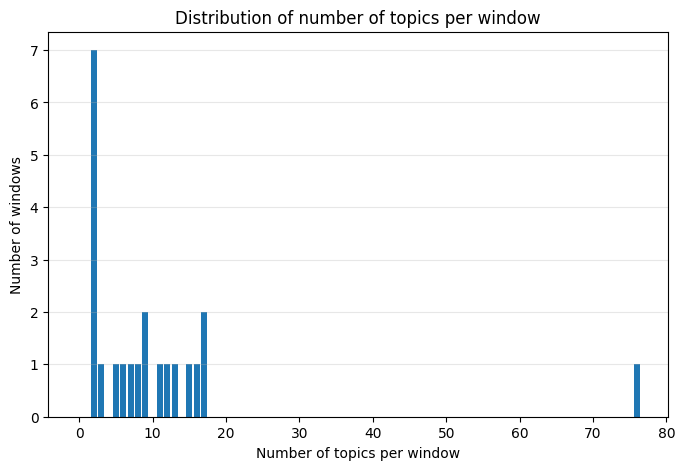

In [ ]:
years = df['year'].unique()
window_topics = []

current = years.min()
end_year = years.max()

while current + window_size <= end_year:
    subset = df[(df['year'] >= current) & (df['year'] < current + window_size)]

    if len(subset) >= 10:
        # Prepare documents
        docs_window = [" ".join(tokens) for tokens in subset['Tokens']]
        doc_embeddings = embedding_model.encode(docs_window)

        # Fit BERTopic
        topic_model = BERTopic(
            embedding_model=None,
            umap_model=None,
            hdbscan_model=hdbscan_model,
            vectorizer_model=vectorizer_model,
            calculate_probabilities=False,
            verbose=False
        )
        topics, _ = topic_model.fit_transform(docs_window, embeddings=doc_embeddings)

        subset = subset.copy().reset_index(drop=True)
        subset['topic_id'] = topics
        subset['embedding'] = list(doc_embeddings)

        # Filter valid topics
        topic_info = topic_model.get_topic_info()
        valid_topics = topic_info[topic_info["Count"] >= min_docs_per_topic]["Topic"].tolist()
        valid_topics = [t for t in valid_topics if t != -1]

        # Topic words
        topic_words_dict = {
            tid: [w for w, _ in topic_model.get_topic(tid)[:top_n_words]]
            for tid in valid_topics
        }

        # Topic embeddings = mean of doc embeddings
        topic_embeddings = {}
        for tid in valid_topics:
            idx = subset.index[subset['topic_id'] == tid].to_numpy()
            topic_embeddings[tid] = doc_embeddings[idx].mean(axis=0)

        # Document counts per topic
        topic_doc_counts = {
            int(row["Topic"]): int(row["Count"])
            for _, row in topic_info.iterrows() if row["Topic"] in valid_topics
        }

        # Save window info
        window_topics.append({
            "start_year": current,
            "end_year": current + window_size,
            "num_docs": len(subset),
            "topic_words": topic_words_dict,
            "topic_doc_counts": topic_doc_counts,
            "topic_embeddings": topic_embeddings,
            "tweets_with_topics": subset.to_dict(orient="records")
        })

    current += step_size

# Save pickle
with open("window_topics.pkl", "wb") as f:
    pickle.dump(window_topics, f)

# Histogram
num_topics_per_window = [len(w["topic_words"]) for w in window_topics]
plt.figure(figsize=(8,5))
plt.hist(num_topics_per_window, bins=range(0, max(num_topics_per_window)+2), align='left', rwidth=0.8)
plt.xlabel("Number of topics per window")
plt.ylabel("Number of windows")
plt.title("Distribution of number of topics per window")
plt.grid(axis='y', alpha=0.3)
plt.show()

 Topic relations between windows

In [9]:
with open("window_topics.pkl", "rb") as f:
    window_topics = pickle.load(f)

In [10]:
relations = []
tweet_to_centroid_threshold = 0.4
similarity_threshold = 0.7
coverage_threshold_forward = 0.3
coverage_threshold_backward = 0.3

def compute_coverage_forward(w1, w2):
    coverages = {}
    w1_docs = pd.DataFrame(w1["tweets_with_topics"])
    w2_docs = pd.DataFrame(w2["tweets_with_topics"])
    w1_docs = w1_docs[w1_docs["topic_id"] != -1]
    w2_docs = w2_docs[w2_docs["topic_id"] != -1]

    t2_ids = [tid for tid in w2["topic_embeddings"].keys() if tid != -1]
    centroids_new = np.array([w2["topic_embeddings"][tid] for tid in t2_ids])

    for tid1 in [tid for tid in w1["topic_embeddings"].keys() if tid != -1]:
        docs_t1 = w1_docs[w1_docs["topic_id"] == tid1]
        if docs_t1.empty:
            continue
        tweet_embs = np.vstack(docs_t1["embedding"].values)
        sim_matrix = cosine_similarity(tweet_embs, centroids_new)
        best_matches = sim_matrix.argmax(axis=1)
        best_scores = sim_matrix.max(axis=1)
        valid_idx = best_scores >= tweet_to_centroid_threshold
        best_matches = best_matches[valid_idx]
        counts_by_idx = np.bincount(best_matches, minlength=len(t2_ids))
        total_old = len(tweet_embs)
        for idx2, cnt in enumerate(counts_by_idx):
            if cnt > 0:
                coverages[(tid1, t2_ids[idx2])] = cnt / total_old
    return coverages

def compute_coverage_backward(w1, w2):
    coverages = {}
    w1_docs = pd.DataFrame(w1["tweets_with_topics"])
    w2_docs = pd.DataFrame(w2["tweets_with_topics"])
    w1_docs = w1_docs[w1_docs["topic_id"] != -1]
    w2_docs = w2_docs[w2_docs["topic_id"] != -1]

    t1_ids = [tid for tid in w1["topic_embeddings"].keys() if tid != -1]
    centroids_old = np.array([w1["topic_embeddings"][tid] for tid in t1_ids])

    for tid2 in [tid for tid in w2["topic_embeddings"].keys() if tid != -1]:
        docs_t2 = w2_docs[w2_docs["topic_id"] == tid2]
        if docs_t2.empty:
            continue
        tweet_embs = np.vstack(docs_t2["embedding"].values)
        sim_matrix = cosine_similarity(tweet_embs, centroids_old)
        best_matches = sim_matrix.argmax(axis=1)
        best_scores = sim_matrix.max(axis=1)
        valid_idx = best_scores >= tweet_to_centroid_threshold
        best_matches = best_matches[valid_idx]
        counts_by_idx = np.bincount(best_matches, minlength=len(t1_ids))
        total_new = len(tweet_embs)
        for idx1, cnt in enumerate(counts_by_idx):
            if cnt > 0:
                coverages[(t1_ids[idx1], tid2)] = cnt / total_new
    return coverages

# Main Loop: Relations
for i in range(len(window_topics)-1):
    w1, w2 = window_topics[i], window_topics[i+1]
    if not w1["topic_embeddings"] or not w2["topic_embeddings"]:
        continue

    t1_ids = list(w1["topic_embeddings"].keys())
    t2_ids = list(w2["topic_embeddings"].keys())
    emb1 = np.array(list(w1["topic_embeddings"].values()))
    emb2 = np.array(list(w2["topic_embeddings"].values()))
    sim_matrix = cosine_similarity(emb1, emb2)

    coverage_f = compute_coverage_forward(w1, w2)
    coverage_b = compute_coverage_backward(w1, w2)

    # Relations: continued, split, disappeared
    for idx1, tid1 in enumerate(t1_ids):
        sims = sim_matrix[idx1]
        connected = [
            t2_ids[idx2]
            for idx2, sim in enumerate(sims)
            if sim >= similarity_threshold
            and coverage_f.get((tid1, t2_ids[idx2]), 0) >= coverage_threshold_forward
            and coverage_b.get((tid1, t2_ids[idx2]), 0) >= coverage_threshold_backward
        ]
        cover_f_vals = [coverage_f.get((tid1,t2),0) for t2 in connected]
        cover_b_vals = [coverage_b.get((tid1,t2),0) for t2 in connected]
        total_f = sum(cover_f_vals)
        total_b = sum(cover_b_vals)

        if not connected or total_f < 0.4 or total_b < 0.4:
            relation = "disappeared"
        elif len(connected)==1 and cover_f_vals[0]>0.5 and cover_b_vals[0]>0.5 and sims[t2_ids.index(connected[0])]>0.9:
            relation = "continued"
        elif len(connected)>=2 and total_f>=0.7 and all(cv>0.5 for cv in cover_b_vals):
            relation = "split"
        else:
            relation = "unclear"

        relations.append({
            "window1": i,
            "topic1": tid1,
            "topic1_words": w1["topic_words"].get(tid1, []),
            "window2": i+1,
            "successors": connected,
            "successors_words": [w2["topic_words"].get(t2, []) for t2 in connected],
            "successors_similarities": [round(sims[t2_ids.index(t2)],3) for t2 in connected],
            "coverage_forward": [round(cv,3) for cv in cover_f_vals],
            "coverage_backward": [round(cv,3) for cv in cover_b_vals],
            "coverage_sum_forward": round(total_f,3),
            "coverage_sum_backward": round(total_b,3),
            "relation": relation
        })

    # Merge detection
    for idx2, tid2 in enumerate(t2_ids):
        sims = sim_matrix[:, idx2]
        connected2 = [
            t1_ids[idx1]
            for idx1, sim in enumerate(sims)
            if sim >= similarity_threshold
            and coverage_f.get((t1_ids[idx1], tid2), 0) >= coverage_threshold_forward
            and coverage_b.get((t1_ids[idx1], tid2), 0) >= coverage_threshold_backward
        ]
        cover_f_vals = [coverage_f.get((t1,t2_ids[idx2]),0) for t1 in connected2]
        cover_b_vals = [coverage_b.get((t1,t2_ids[idx2]),0) for t1 in connected2]
        total_f = sum(cover_f_vals)
        total_b = sum(cover_b_vals)

        if len(connected2)>=2 and total_b>=0.7 and all(cv>0.5 for cv in cover_f_vals):
            relations.append({
                "window1": i,
                "topics_from": connected2,
                "topics_from_words": [w1["topic_words"].get(tid,[]) for tid in connected2],
                "window2": i+1,
                "topic_to": tid2,
                "topic_to_words": w2["topic_words"].get(tid2,[]),
                "antecedents_similarities": [round(sim_matrix[t1_ids.index(tid), idx2],3) for tid in connected2],
                "coverage_forward": [round(cv,3) for cv in cover_f_vals],
                "coverage_backward": [round(cv,3) for cv in cover_b_vals],
                "coverage_sum_forward": round(total_f,3),
                "coverage_sum_backward": round(total_b,3),
                "relation": "merge"
            })

# Remove false positives
merged_from_pairs = set()
for r in relations:
    if r.get("relation")=="merge":
        merged_from_pairs.update([(r["window1"], tid) for tid in r["topics_from"]])

relations = [
    r for r in relations
    if not (
        r["relation"] in ["disappeared","unclear", "continued"] and (r["window1"], r.get("topic1",-1)) in merged_from_pairs
    )
]

df_final_relations = pd.DataFrame(relations)

In [11]:
df_final_relations["relation"].value_counts()

,count
relation,
continued,709
disappeared,706
unclear,286
split,52
merge,51


Metrics

In [ ]:
# ===============================================================
# Topic Quality computation
# ===============================================================

def compute_tq_slice(topic_words_dict, docs, dictionary, top_n=10):

    topic_words = [words[:top_n] for words in topic_words_dict.values() if words]
    if not topic_words:
        return None, None, None, None, None

    texts = [doc.split() for doc in docs]

    # ---- Coherence ----
    cm_cv = CoherenceModel(topics=topic_words, texts=texts, dictionary=dictionary, coherence='c_v')
    cm_npmi = CoherenceModel(topics=topic_words, texts=texts, dictionary=dictionary, coherence='c_npmi')
    cm_umass = CoherenceModel(topics=topic_words, texts=texts, dictionary=dictionary, coherence='u_mass')

    cv_scores = cm_cv.get_coherence_per_topic()
    npmi_scores = cm_npmi.get_coherence_per_topic()
    umass_scores = cm_umass.get_coherence_per_topic()

    # ---- Diversity ----
    K = len(topic_words)
    diversities = []
    for k, words_k in enumerate(topic_words):
        overlaps = 0
        for i, words_j in enumerate(topic_words):
            if i == k:
                continue
            overlaps += len(set(words_k) & set(words_j)) / len(words_k)
        redundancy = overlaps / (K - 1) if K > 1 else 0
        diversities.append(1 - redundancy)

    tq = np.mean([c * d for c, d in zip(cv_scores, diversities)])

    return (
        tq,
        np.mean(cv_scores),
        np.mean(diversities),
        np.mean(npmi_scores),
        np.mean(umass_scores)
    )


# ===============================================================
# Compute window-level topic quality
# ===============================================================

dictionary = Dictionary([" ".join(x).split() for x in df["Tokens"]])

final_rows = []

for w in window_topics:

    window_docs = [" ".join(item["Tokens"]) for item in w["tweets_with_topics"]]

    valid_topics = dict(sorted(
        ((tid, words) for tid, words in w["topic_words"].items() if len(words) > 0),
        key=lambda x: x[0]
    ))

    tq, cv, diversity, npmi, umass = compute_tq_slice(
        valid_topics,
        window_docs,
        dictionary,
        top_n=top_n_words
    )

    topic_strings = [" | ".join(words) for words in valid_topics.values()]
    topic_counts_list = [w["topic_doc_counts"].get(tid, 0) for tid in valid_topics.keys()]

    final_rows.append({
        "start_year": w["start_year"],
        "end_year": w["end_year"],
        "num_docs": w["num_docs"],
        "cv": cv,
        "npmi": npmi,
        "umass": umass,
        "diversity": diversity,
        "tq": tq,
        "topics": topic_strings,
        "topic_doc_counts": topic_counts_list
    })

df_final = pd.DataFrame(final_rows)
print(df_final.head())


# ===============================================================
# Expand topics → one row per topic
# ===============================================================

rows = []

for i, window in enumerate(window_topics):
    start_year = window["start_year"]
    end_year = window["end_year"]
    topic_words = window["topic_words"]
    topic_doc_counts = window["topic_doc_counts"]

    tweets_data = pd.DataFrame(window["tweets_with_topics"])

    for topic_id, words in topic_words.items():
        if topic_id == -1:
            continue

        num_docs = topic_doc_counts.get(topic_id, 0)

        topic_tweets = tweets_data[tweets_data["topic_id"] == topic_id]

        if len(topic_tweets) > 0:
            sampled_texts = topic_tweets.sample(
                n=min(5, len(topic_tweets)),
                random_state=42
            )["Tokens"].apply(lambda x: " ".join(x)).tolist()
        else:
            sampled_texts = []

        rows.append({
            "window_id": i,
            "topic_id": topic_id,
            "start_year": start_year,
            "end_year": end_year,
            "num_docs": num_docs,
            "words": ", ".join(words[:10]),
            "representative_texts": " | ".join(sampled_texts)
        })

df_topics = pd.DataFrame(rows)


# ===============================================================
# Create grouped compact table
# ===============================================================

df_grouped = (
    df_topics.groupby(["window_id", "start_year", "end_year"], sort=False)
    .agg({
        "num_docs": lambda x: list(x),
        "words": lambda x: str([w.replace(", ", "|") for w in x]),
        "representative_texts": lambda x: str([t.replace(" | ", "||") for t in x]),
    })
    .reset_index()
    .rename(columns={
        "num_docs": "topic_doc_counts",
        "words": "topics",
        "representative_texts": "representative_texts"
    })
)

df_grouped.head()

   start_year  end_year  num_docs        cv      npmi     umass  diversity  \
0        1970      1973       358  0.533891  0.067366 -0.229631    0.80000   
1        1972      1975       462  0.503667  0.044572 -0.372660    0.80000   
2        1974      1977       453  0.530547  0.047326 -0.273652    0.80000   
3        1976      1979       632  0.571920  0.066692 -0.321003    0.82381   
4        1978      1981       619  0.523302  0.042489 -0.182032    0.80000   

         tq                                             topics  \
0  0.427112  [power | republic | africa | delegation | char...   
1  0.402934  [power | africa | delegation | relation | inte...   
2  0.424437  [africa | south | power | delegation | indepen...   
3  0.477385  [africa | republic | delegation | independence...   
4  0.418642  [africa | south | independence | relation | re...   

               topic_doc_counts  
0                     [274, 32]  
1                     [390, 45]  
2                     [393, 28] 

,window_id,start_year,end_year,topic_doc_counts,topics,representative_texts
0,0,1970,1973,"[274, 32]",['power|republic|africa|delegation|charter|rel...,['associate delegation sentiment congratulate ...
1,1,1972,1975,"[390, 45]",['power|africa|delegation|relation|interest|re...,['join speak farin congratulate presidency gui...
2,2,1974,1977,"[393, 28]",['africa|south|power|delegation|independence|s...,['congratulate warmly chair quality long exper...
3,3,1976,1979,"[82, 82, 76, 64, 37, 30, 26]",['africa|republic|delegation|independence|rela...,['pleased congratulate ambassador amerasinghe ...
4,4,1978,1981,"[552, 67]",['africa|south|independence|relation|republic|...,['pleasure satisfaction delegation ambassador ...


Saving

In [ ]:
df_grouped.rename(columns={
    "start_year": "start_date",
    "end_year": "end_date",
    "representative_texts": "representative_tweets"
}, inplace=True)

df_grouped["start_date"] = pd.to_datetime(df_grouped["start_date"].astype(str) + "-01-01")
df_grouped["end_date"]   = pd.to_datetime(df_grouped["end_date"].astype(str) + "-12-31")

UN

In [ ]:
df_grouped.to_csv("un_bertilda_topics_per_window.csv", index=False)
df_final.to_csv("un_bertilda_quality_scores.csv", index=False)
df_final_relations.to_csv("un_bertilda_merge_split_relations.csv", index=False)

State of Union

In [ ]:
df_grouped.to_csv("stateofunion_bertilda_topics_per_window.csv", index=False)
df_final.to_csv("stateofunion_bertilda_quality_scores.csv", index=False)
df_final_relations.to_csv("stateofunion_bertilda_merge_split_relations.csv", index=False)

In [12]:
df_final_relations.to_csv("stateofunion_bertilda_merge_split_relations.csv", index=False)